In [2]:
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

uploaded = files.upload()

Saving loanapproval.csv to loanapproval.csv


In [3]:
df = pd.read_csv("loanapproval.csv")
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


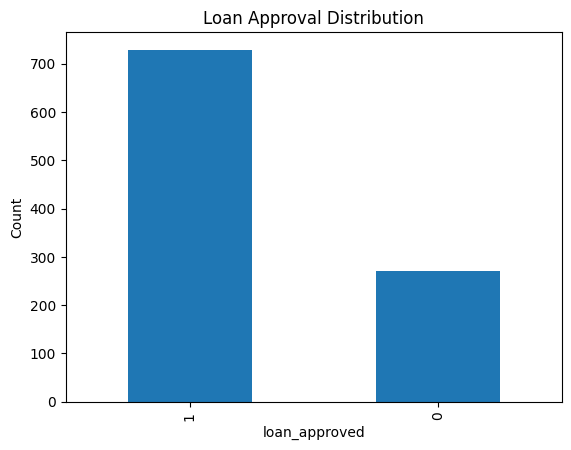

In [4]:
#Bar Chart
df['loan_approved'].value_counts().plot(kind='bar')
plt.title("Loan Approval Distribution")
plt.ylabel("Count")
plt.show()

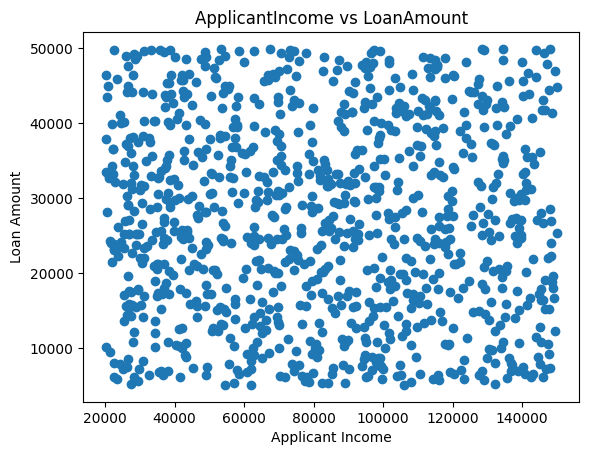

In [5]:
#Scatter plot
plt.scatter(df['annual_income'], df['loan_amount'])
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("ApplicantIncome vs LoanAmount")
plt.show()

In [6]:
df[['annual_income','loan_amount']].corr()

,annual_income,loan_amount
annual_income,1.000000,-0.024862
loan_amount,-0.024862,1.000000


In [7]:
# The scatter plot shows a wide spread of loan amounts across all income levels,
# suggesting little to no linear relationship between annual income and loan amount in this dataset.
# This is supported by a near-zero correlation value.

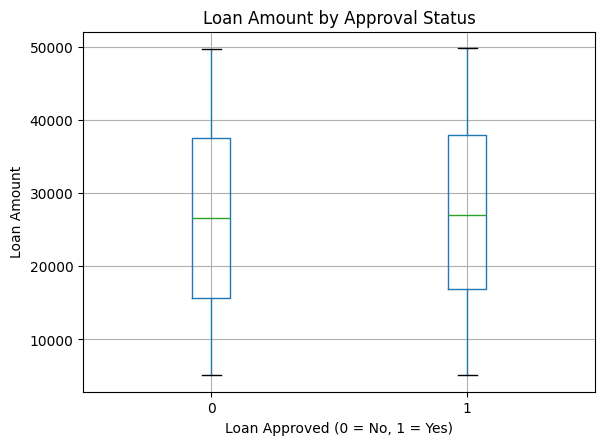

In [8]:
df.boxplot(column='loan_amount', by='loan_approved')
plt.title("Loan Amount by Approval Status")
plt.suptitle("")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Loan Amount")
plt.show()

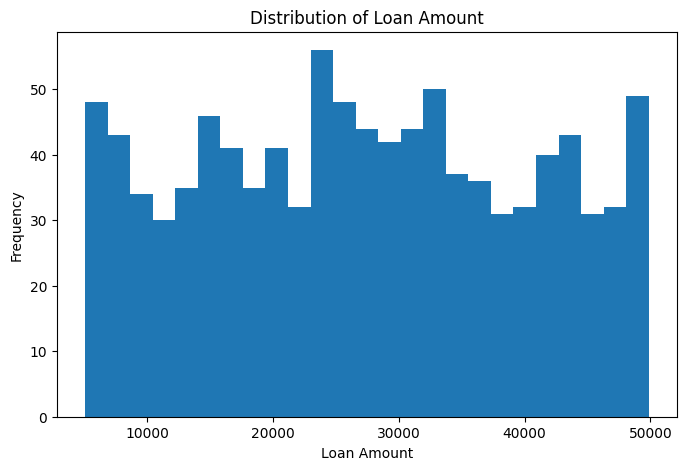

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['loan_amount'], bins=25)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

In [10]:
missing = df.isnull().sum()
missing

,0
applicant_id,0
age,0
gender,0
marital_status,0
annual_income,0
loan_amount,0
credit_score,0
num_dependents,0
existing_loans_count,0
employment_status,0


In [11]:
df_before_missing = df.copy()

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum()

,0
applicant_id,0
age,0
gender,0
marital_status,0
annual_income,0
loan_amount,0
credit_score,0
num_dependents,0
existing_loans_count,0
employment_status,0


In [13]:
#Outlier Detection and Handling

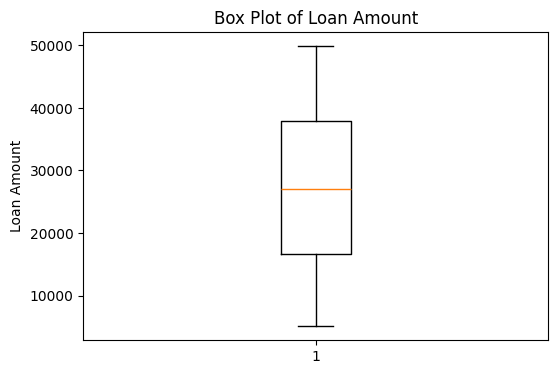

In [14]:
plt.figure(figsize=(6,4))
plt.boxplot(df['loan_amount'])
plt.title("Box Plot of Loan Amount")
plt.ylabel("Loan Amount")
plt.show()

In [15]:
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR

(np.float64(16587.5), np.float64(37939.25), np.float64(21351.75))

In [16]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['loan_amount'] < lower_bound) |
    (df['loan_amount'] > upper_bound)
]

outliers[['loan_amount']].head()


,loan_amount


In [17]:
outliers = df[
    (df['loan_amount'] < lower_bound) |
    (df['loan_amount'] > upper_bound)
]

outliers


,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved


In [23]:
#Data Reduction
df.shape #----> (1000,11)
df_sampled = df.sample(frac=0.6, random_state=42)
df_sampled.shape

(600, 11)

In [24]:
df_sampled.columns

Index(['applicant_id', 'age', 'gender', 'marital_status', 'annual_income',
       'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='object')

In [25]:
# Dropping less relevant identifier column
df_reduced = df_sampled.drop(columns=['applicant_id'])
df_reduced.columns

Index(['age', 'gender', 'marital_status', 'annual_income', 'loan_amount',
       'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='object')

In [26]:
df_reduced[['annual_income']].head()

,annual_income
521,68781
737,26796
740,63056
660,79871
411,148734


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_reduced['annual_income_scaled'] = scaler.fit_transform(
    df_reduced[['annual_income']]
)
df_reduced[['annual_income', 'annual_income_scaled']].head()

,annual_income,annual_income_scaled
521,68781,0.374634
737,26796,0.051165
740,63056,0.330526
660,79871,0.460076
411,148734,0.990624


In [28]:
df_reduced['income_category'] = pd.cut(
    df_reduced['annual_income'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df_reduced[['annual_income', 'income_category']].head()

,annual_income,income_category
521,68781,Medium
737,26796,Low
740,63056,Low
660,79871,Medium
411,148734,High


In [29]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 521 to 743
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   600 non-null    int64   
 1   gender                600 non-null    object  
 2   marital_status        600 non-null    object  
 3   annual_income         600 non-null    int64   
 4   loan_amount           600 non-null    int64   
 5   credit_score          600 non-null    int64   
 6   num_dependents        600 non-null    int64   
 7   existing_loans_count  600 non-null    int64   
 8   employment_status     600 non-null    object  
 9   loan_approved         600 non-null    int64   
 10  annual_income_scaled  600 non-null    float64 
 11  income_category       600 non-null    category
dtypes: category(1), float64(1), int64(7), object(3)
memory usage: 57.0+ KB


In [30]:
df_reduced.describe()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved,annual_income_scaled
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,42.466667,80452.740000,26779.193333,578.025000,2.053333,2.003333,0.726667,0.464558
std,12.555675,37804.042772,12825.890271,159.652987,1.414387,1.442263,0.446042,0.291257
min,21.000000,20155.000000,5082.000000,301.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,46900.750000,15879.500000,440.000000,1.000000,1.000000,0.000000,0.206060
50%,43.000000,78683.500000,25969.000000,570.000000,2.000000,2.000000,1.000000,0.450927
75%,53.000000,112161.000000,37246.750000,724.000000,3.000000,3.000000,1.000000,0.708851
max,64.000000,149951.000000,49859.000000,849.000000,4.000000,4.000000,1.000000,1.000000


In [31]:
loan_min = df_reduced['loan_amount'].min()
loan_max = df_reduced['loan_amount'].max()
loan_mean = df_reduced['loan_amount'].mean()
loan_median = df_reduced['loan_amount'].median()
loan_mode = df_reduced['loan_amount'].mode()

loan_min, loan_max, loan_mean, loan_median, loan_mode

(5082,
 49859,
 np.float64(26779.193333333333),
 25969.0,
 0    13016
 1    14171
 2    17297
 3    26281
 4    32990
 Name: loan_amount, dtype: int64)

In [32]:
# Range
loan_range = df_reduced['loan_amount'].max() - df_reduced['loan_amount'].min()

# Quartiles
Q1 = df_reduced['loan_amount'].quantile(0.25)
Q2 = df_reduced['loan_amount'].quantile(0.50)
Q3 = df_reduced['loan_amount'].quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

# Variance and Standard Deviation
variance = df_reduced['loan_amount'].var()
std_dev = df_reduced['loan_amount'].std()

loan_range, Q1, Q2, Q3, IQR, variance, std_dev

(44777,
 np.float64(15879.5),
 np.float64(25969.0),
 np.float64(37246.75),
 np.float64(21367.25),
 164503461.23801875,
 12825.89027077726)

In [33]:
df_reduced.corr(numeric_only=True)

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved,annual_income_scaled
age,1.000000,0.034610,0.007028,0.098489,-0.031110,0.096346,0.008506,0.034610
annual_income,0.034610,1.000000,0.043581,0.031490,-0.043487,-0.045092,0.200433,1.000000
loan_amount,0.007028,0.043581,1.000000,0.090734,-0.012824,-0.027560,0.048401,0.043581
credit_score,0.098489,0.031490,0.090734,1.000000,-0.091414,0.022403,0.355990,0.031490
num_dependents,-0.031110,-0.043487,-0.012824,-0.091414,1.000000,0.047379,-0.360559,-0.043487
existing_loans_count,0.096346,-0.045092,-0.027560,0.022403,0.047379,1.000000,-0.325563,-0.045092
loan_approved,0.008506,0.200433,0.048401,0.355990,-0.360559,-0.325563,1.000000,0.200433
annual_income_scaled,0.034610,1.000000,0.043581,0.031490,-0.043487,-0.045092,0.200433,1.000000
